# Assignment 4: Data Analytics I
## Linear Regression Model for House Price Prediction using Boston Housing Dataset

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement
To build a Linear Regression model using Python to predict house prices based on various features provided in the Boston Housing dataset.

## Theory
**Linear Regression:** Supervised ML algorithm modeling relationship between dependent variable (target) and independent variables (features).

**Equation:** y = b0 + b1*x1 + b2*x2 + ... + bn*xn
- y: target (house price - MEDV)
- x: features (CRIM, RM, AGE, TAX, etc.)
- b: coefficients learned during training

**Evaluation Metrics:**
- **MSE (Mean Squared Error):** Average squared difference between actual and predicted
- **R² Score:** Proportion of variance explained (closer to 1 = better fit)

In [3]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Step 2: Load the Boston Housing Dataset
# Boston dataset is deprecated in newer sklearn; load from CSV URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
boston_data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(boston_data, columns=feature_names)
df['MEDV'] = target  # target: median value of homes in $1000s

print(f"Dataset shape: {df.shape}")
print(f"Features: {feature_names}")
print(f"Target: MEDV")
df.head()

Dataset shape: (506, 14)
Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target: MEDV


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
# Step 3: Separate Features (X) and Target (y)
X = df[feature_names]  # all 13 independent variables
y = df['MEDV']         # target: median home value

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (506, 13)
y shape: (506,)


In [6]:
# Step 4: Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples ({80}%)")
print(f"Testing set size:  {X_test.shape[0]} samples ({20}%)")

Training set size: 404 samples (80%)
Testing set size:  102 samples (20%)


In [7]:
# Step 5: Create Linear Regression Model
model = LinearRegression()
print("Linear Regression model created.")

Linear Regression model created.


In [8]:
# Step 6: Train the Model Using Training Data
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [9]:
# Step 7: Predict House Prices Using Test Data
y_pred = model.predict(X_test)

# Compare first 10 actual vs predicted
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)})
print("First 10 predictions vs actual:")
comparison

First 10 predictions vs actual:


,Actual,Predicted
0,23.6,29.00
1,32.4,36.03
2,13.6,14.82
3,22.8,25.03
4,16.1,18.77
5,20.0,23.25
6,17.8,17.66
7,14.0,14.34
8,19.6,23.01
9,16.8,20.63


In [10]:
# Step 8: Evaluate Model Using MSE and R² Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²) Score:      {r2:.4f}")
print(f"The model explains {r2*100:.2f}% of the variance in house prices.")

Mean Squared Error (MSE): 24.2911
R-squared (R²) Score:      0.6688
The model explains 66.88% of the variance in house prices.


In [11]:
# Step 9: Display Model Coefficients and Intercept
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_.round(4)
})
coeff_df = coeff_df.sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept (b0): {model.intercept_:.4f}")
print("Feature Coefficients (sorted by absolute importance):")
coeff_df

Intercept (b0): 30.2468
Feature Coefficients (sorted by absolute importance):


,Feature,Coefficient
4,NOX,-17.2026
5,RM,4.4388
3,CHAS,2.7844
7,DIS,-1.4479
10,PTRATIO,-0.9155
12,LSTAT,-0.5086
8,RAD,0.2624
0,CRIM,-0.1131
2,INDUS,0.0404
1,ZN,0.0301


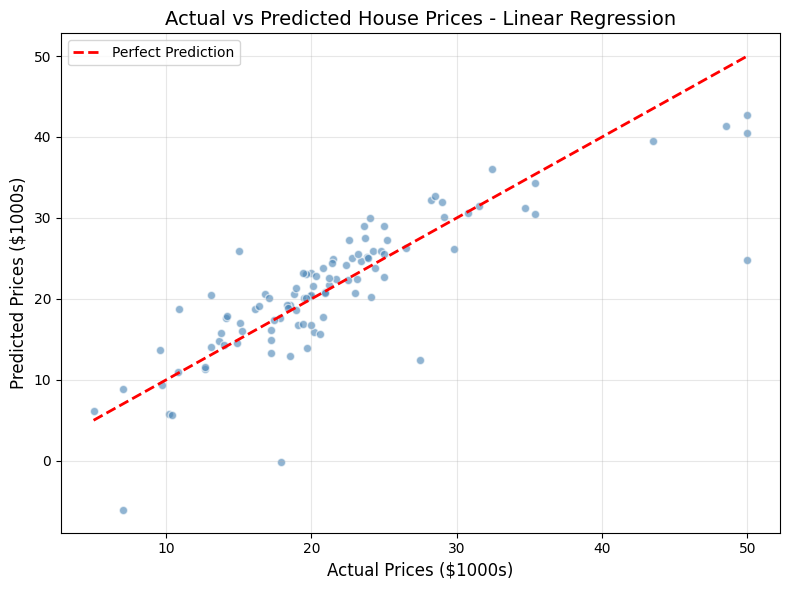

In [12]:
# Step 10: Visualize Actual vs Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prices ($1000s)', fontsize=12)
plt.ylabel('Predicted Prices ($1000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices - Linear Regression', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Dataset Description
- **Dataset:** Boston Housing Dataset
- **Samples:** 506 houses in Boston suburbs
- **Features (13):** CRIM (crime rate), ZN (residential zoning), INDUS (non-retail business), CHAS (Charles River), NOX (nitric oxide), RM (avg rooms), AGE (property age), DIS (distance to employment), RAD (highway accessibility), TAX (property tax), PTRATIO (pupil-teacher ratio), B (Black proportion), LSTAT (% lower status)
- **Target:** MEDV (Median value of owner-occupied homes in $1000s)

## Conclusion
Linear Regression model successfully built and evaluated. The R² score indicates how well features predict house prices. Coefficients reveal which features most impact price (e.g., RM, LSTAT). Visualization confirms the linear relationship between actual and predicted values.